### 1.1
数据图文件parler.txt的部分内容，要改成G-CARE 数据图的格式，同时将这个数据图改成无向图
，下面是该数据图对应查询文件的格式（对于顶点第一列是v，第二列是编号，第三列是标签，第四列是在查询图中的度数），也是帮我改成G-CARE 查询图的格式（第四列是bound，统一改成-1），

In [1]:
import os
import glob
import sys

# ==========================================
# 1. 数据图转换函数 (Data Graph Converter)
# ==========================================
def convert_data_graph(input_path, output_path, graph_id=0):
    """
    将原始数据图转换为 G-CARE 格式，并处理为无向图（双向边）。
    """
    if not os.path.exists(input_path):
        print(f"[Error] 数据图文件不存在: {input_path}")
        return

    vertices = []
    edges = set() # 使用集合去重

    print(f"正在读取数据图: {input_path} ...")
    
    try:
        with open(input_path, 'r') as f_in:
            for line in f_in:
                parts = line.strip().split()
                if not parts:
                    continue
                
                tag = parts[0]
                
                if tag == 'v':
                    # 原始: v <id> <label> <degree>
                    # 目标: v <id> <label>
                    v_id = int(parts[1])
                    v_label = int(parts[2])
                    vertices.append((v_id, v_label))
                    
                elif tag == 'e':
                    # 原始: e <src> <dst>
                    # 目标: e <src> <dst> <label=0> (双向)
                    src = int(parts[1])
                    dst = int(parts[2])
                    
                    # 显式添加双向边以模拟无向图
                    edges.add((src, dst, 0))
                    edges.add((dst, src, 0))
        
        # G-CARE 要求顶点按 ID 升序
        vertices.sort(key=lambda x: x[0])
        sorted_edges = sorted(list(edges), key=lambda x: (x[0], x[1]))

        print(f"数据图统计: 顶点 {len(vertices)} 个, 边 {len(sorted_edges)} 条 (已双向化)")
        print(f"正在写入: {output_path} ...")

        with open(output_path, 'w') as f_out:
            # Header: t # <graph_id>
            f_out.write(f"t # {graph_id}\n")
            
            for v_id, v_label in vertices:
                f_out.write(f"v {v_id} {v_label}\n")
            
            for src, dst, label in sorted_edges:
                f_out.write(f"e {src} {dst} {label}\n")
                
        print(">>> 数据图转换成功！\n")

    except Exception as e:
        print(f"[Error] 转换数据图时出错: {e}")

# ==========================================
# 2. 查询图转换函数 (Query Graph Converter)
# ==========================================
def convert_single_query(input_path, output_path, query_id):
    """转换单个查询图文件"""
    vertices = []
    edges = []

    try:
        with open(input_path, 'r') as f_in:
            for line in f_in:
                parts = line.strip().split()
                if not parts: continue
                tag = parts[0]
                
                if tag == 'v':
                    # 原始: v <id> <label> <degree>
                    # 目标: v <id> <label> <dvid=-1>
                    v_id = int(parts[1])
                    v_label = int(parts[2])
                    vertices.append((v_id, v_label, -1))
                    
                elif tag == 'e':
                    # 原始: e <src> <dst>
                    # 目标: e <src> <dst> <label=0>
                    src = int(parts[1])
                    dst = int(parts[2])
                    edges.append((src, dst, 0))

        vertices.sort(key=lambda x: x[0])

        with open(output_path, 'w') as f_out:
            # Header: t # s <query_id> (注意有 's')
            f_out.write(f"t # s {query_id}\n")
            
            for v in vertices:
                f_out.write(f"v {v[0]} {v[1]} {v[2]}\n")
            
            for e in edges:
                f_out.write(f"e {e[0]} {e[1]} {e[2]}\n")
        return True
    except Exception as e:
        print(f"转换查询 {input_path} 失败: {e}")
        return False

def batch_process_queries(input_dir, output_dir):
    """批处理查询图"""
    if not os.path.exists(input_dir):
        print(f"[Error] 查询输入目录不存在: {input_dir}")
        return
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)
        print(f"创建查询输出目录: {output_dir}")

    # 查找所有 .graph 文件
    files = glob.glob(os.path.join(input_dir, "*.graph"))
    files.sort()
    
    print(f"找到 {len(files)} 个查询文件，开始转换...")
    
    count = 0
    for i, file_path in enumerate(files):
        filename = os.path.basename(file_path)
        new_filename = os.path.splitext(filename)[0] + ".txt"
        output_path = os.path.join(output_dir, new_filename)
        
        # 使用循环索引 i 作为 query_id
        if convert_single_query(file_path, output_path, i):
            count += 1
            if count % 10 == 0: # 每10个打印一次进度
                print(f"已处理 {count}/{len(files)}...")

    print(f">>> 查询图批处理完成！成功转换 {count} 个文件。\n")

# ==========================================
# 3. 主程序入口 (配置路径)
# ==========================================
if __name__ == "__main__":
    
    # --- 配置 A: 数据图路径 ---
    # 原始数据图文件
    RAW_DATA_GRAPH = "/home/wangshuo/resource/datasets/graph_data/dataset/parler/parler.txt"
    # 转换后输出位置 (建议文件名加上 _gcare 以示区别)
    OUTPUT_DATA_GRAPH = "/home/wangshuo/resource/datasets/graph_data/dataset/parler/parler_gcare.txt"
    
    # --- 配置 B: 查询图目录 ---
    # 原始查询图文件夹
    RAW_QUERY_DIR = "/home/wangshuo/resource/datasets/graph_data/queryset/parler"
    # 转换后输出文件夹 (脚本会自动创建)
    OUTPUT_QUERY_DIR = "/home/wangshuo/resource/datasets/graph_data/queryset/parler_gcare"

    print("=== 开始 G-CARE 格式转换任务 ===")
    
    # 1. 执行数据图转换
    convert_data_graph(RAW_DATA_GRAPH, OUTPUT_DATA_GRAPH, graph_id=0)
    
    # 2. 执行查询图批处理
    batch_process_queries(RAW_QUERY_DIR, OUTPUT_QUERY_DIR)
    
    print("=== 所有任务结束 ===")
    print(f"G-CARE 数据图: {OUTPUT_DATA_GRAPH}")
    print(f"G-CARE 查询集: {OUTPUT_QUERY_DIR}")

=== 开始 G-CARE 格式转换任务 ===
正在读取数据图: /home/wangshuo/resource/datasets/graph_data/dataset/parler/parler.txt ...
数据图统计: 顶点 195812 个, 边 755316 条 (已双向化)
正在写入: /home/wangshuo/resource/datasets/graph_data/dataset/parler/parler_gcare.txt ...
>>> 数据图转换成功！

创建查询输出目录: /home/wangshuo/resource/datasets/graph_data/queryset/parler_gcare
找到 16 个查询文件，开始转换...
已处理 10/16...
>>> 查询图批处理完成！成功转换 16 个文件。

=== 所有任务结束 ===
G-CARE 数据图: /home/wangshuo/resource/datasets/graph_data/dataset/parler/parler_gcare.txt
G-CARE 查询集: /home/wangshuo/resource/datasets/graph_data/queryset/parler_gcare


### 1.2 将原始数据图转换为 G-CARE 格式，并处理为无向图（双向边）。

In [15]:
import os
import glob
import sys

# ==========================================
# 1. 数据图转换函数 (Data Graph Converter)
# ==========================================
def convert_data_graph(input_path, output_path, graph_id=0):
    """
    将原始数据图转换为 G-CARE 格式，并处理为无向图（双向边）。
    """
    if not os.path.exists(input_path):
        print(f"[Error] 数据图文件不存在: {input_path}")
        return

    vertices = []
    edges = set() # 使用集合去重

    print(f"正在读取数据图: {input_path} ...")
    
    try:
        with open(input_path, 'r') as f_in:
            for line in f_in:
                parts = line.strip().split()
                if not parts:
                    continue
                
                tag = parts[0]
                
                if tag == 'v':
                    # 原始: v <id> <label> <degree>
                    # 目标: v <id> <label>
                    v_id = int(parts[1])
                    v_label = int(parts[2])
                    vertices.append((v_id, v_label))
                    
                elif tag == 'e':
                    # 原始: e <src> <dst>
                    # 目标: e <src> <dst> <label=0> (双向)
                    src = int(parts[1])
                    dst = int(parts[2])
                    
                    # 显式添加双向边以模拟无向图
                    edges.add((src, dst, 0))
                    edges.add((dst, src, 0))
        
        # G-CARE 要求顶点按 ID 升序
        vertices.sort(key=lambda x: x[0])
        sorted_edges = sorted(list(edges), key=lambda x: (x[0], x[1]))

        print(f"数据图统计: 顶点 {len(vertices)} 个, 边 {len(sorted_edges)} 条 (已双向化)")
        print(f"正在写入: {output_path} ...")

        with open(output_path, 'w') as f_out:
            # Header: t # <graph_id>
            f_out.write(f"t # {graph_id}\n")
            
            for v_id, v_label in vertices:
                f_out.write(f"v {v_id} {v_label}\n")
            
            for src, dst, label in sorted_edges:
                f_out.write(f"e {src} {dst} {label}\n")
                
        print(">>> 数据图转换成功！\n")

    except Exception as e:
        print(f"[Error] 转换数据图时出错: {e}")

# ==========================================
# 2. 查询图转换函数 (Query Graph Converter)
# ==========================================
def convert_single_query(input_path, output_path, query_id):
    """转换单个查询图文件"""
    vertices = []
    edges = []

    try:
        with open(input_path, 'r') as f_in:
            for line in f_in:
                parts = line.strip().split()
                if not parts: continue
                tag = parts[0]
                
                if tag == 'v':
                    # 原始: v <id> <label> <degree>
                    # 目标: v <id> <label> <dvid=-1>
                    v_id = int(parts[1])
                    v_label = int(parts[2])
                    vertices.append((v_id, v_label, -1))
                    
                elif tag == 'e':
                    # 原始: e <src> <dst>
                    # 目标: e <src> <dst> <label=0>
                    src = int(parts[1])
                    dst = int(parts[2])
                    edges.append((src, dst, 0))

        vertices.sort(key=lambda x: x[0])

        with open(output_path, 'w') as f_out:
            # Header: t # s <query_id> (注意有 's')
            f_out.write(f"t # s {query_id}\n")
            
            for v in vertices:
                f_out.write(f"v {v[0]} {v[1]} {v[2]}\n")
            
            for e in edges:
                f_out.write(f"e {e[0]} {e[1]} {e[2]}\n")
        return True
    except Exception as e:
        print(f"转换查询 {input_path} 失败: {e}")
        return False

def batch_process_queries(input_dir, output_dir):
    """批处理查询图"""
    if not os.path.exists(input_dir):
        print(f"[Error] 查询输入目录不存在: {input_dir}")
        return
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)
        print(f"创建查询输出目录: {output_dir}")

    # 查找所有 .graph 文件
    files = glob.glob(os.path.join(input_dir, "*.graph"))
    files.sort()
    
    print(f"找到 {len(files)} 个查询文件，开始转换...")
    
    count = 0
    for i, file_path in enumerate(files):
        filename = os.path.basename(file_path)
        new_filename = os.path.splitext(filename)[0] + ".txt"
        output_path = os.path.join(output_dir, new_filename)
        
        # 使用循环索引 i 作为 query_id
        if convert_single_query(file_path, output_path, i):
            count += 1
            if count % 10 == 0: # 每10个打印一次进度
                print(f"已处理 {count}/{len(files)}...")

    print(f">>> 查询图批处理完成！成功转换 {count} 个文件。\n")

# ==========================================
# 3. 主程序入口 (配置路径)
# ==========================================
if __name__ == "__main__":
    
    # --- 配置 A: 数据图路径 ---
    # 原始数据图文件
    RAW_DATA_GRAPH = "/home/wangshuo/resource/datasets/graph_data/dataset/parler/parler.txt"
    # 转换后输出位置 (建议文件名加上 _gcare 以示区别)
    OUTPUT_DATA_GRAPH = "/home/wangshuo/resource/datasets/graph_data/dataset/parler/parler_gcare.txt"
    
    # --- 配置 B: 查询图目录 ---
    # 原始查询图文件夹
    RAW_QUERY_DIR = "/home/wangshuo/resource/datasets/graph_data/queryset/parler"
    # 转换后输出文件夹 (脚本会自动创建)
    OUTPUT_QUERY_DIR = "/home/wangshuo/resource/datasets/graph_data/queryset/parler_gcare"

    print("=== 开始 G-CARE 格式转换任务 ===")
    
    # 1. 执行数据图转换
    convert_data_graph(RAW_DATA_GRAPH, OUTPUT_DATA_GRAPH, graph_id=0)
    
    # 2. 执行查询图批处理
    batch_process_queries(RAW_QUERY_DIR, OUTPUT_QUERY_DIR)
    
    print("=== 所有任务结束 ===")
    print(f"G-CARE 数据图: {OUTPUT_DATA_GRAPH}")
    print(f"G-CARE 查询集: {OUTPUT_QUERY_DIR}")

=== 开始 G-CARE 格式转换任务 ===
正在读取数据图: /home/wangshuo/resource/datasets/graph_data/dataset/parler/parler.txt ...
数据图统计: 顶点 195812 个, 边 755316 条 (已双向化)
正在写入: /home/wangshuo/resource/datasets/graph_data/dataset/parler/parler_gcare.txt ...
>>> 数据图转换成功！

找到 246 个查询文件，开始转换...
已处理 10/246...
已处理 20/246...
已处理 30/246...
已处理 40/246...
已处理 50/246...
已处理 60/246...
已处理 70/246...
已处理 80/246...
已处理 90/246...
已处理 100/246...
已处理 110/246...
已处理 120/246...
已处理 130/246...
已处理 140/246...
已处理 150/246...
已处理 160/246...
已处理 170/246...
已处理 180/246...
已处理 190/246...
已处理 200/246...
已处理 210/246...
已处理 220/246...
已处理 230/246...
已处理 240/246...
>>> 查询图批处理完成！成功转换 246 个文件。

=== 所有任务结束 ===
G-CARE 数据图: /home/wangshuo/resource/datasets/graph_data/dataset/parler/parler_gcare.txt
G-CARE 查询集: /home/wangshuo/resource/datasets/graph_data/queryset/parler_gcare


### 1.3 
parler_alley_query.txt 的alley估计结果的内容，上面是真实结果 parler_ans.txt 的内容，请分别结算相对误差和Q_error，同时画出箱型图，写python代码实现

#### 1.3.1 绝对误差和绝对Q_error

成功加载真实值文件，共 65 条记录。
成功加载估计值文件，共 16 条记录。

Query Name                | True Card    | Est Card     | Rel Error  | Q-Error   
query_dense_1_1           | 129165       | 129927       | 0.0059     | 1.0059
query_path_6_2            | 43450497     | 16957773     | 0.6097     | 2.5623
query_dense_1_3           | 3789334      | 3086388      | 0.1855     | 1.2278
query_path_4_0            | 4079965      | 3867048      | 0.0522     | 1.0551
query_path_6_1            | 1039241      | 1333907      | 0.2835     | 1.2835
query_tree_4_1            | 39025        | 37674        | 0.0346     | 1.0358
query_dense_1_2           | 24794        | 27201        | 0.0971     | 1.0971
query_path_6_3            | 1632383      | 1626193      | 0.0038     | 1.0038
query_path_4_2            | 2872354      | 2749760      | 0.0427     | 1.0446
query_path_8_3            | 13826981     | 26292735     | 0.9016     | 1.9016
query_path_8_2            | 4610138      | 2991186      | 0.3512     | 1.5412
query_tree_4_2     

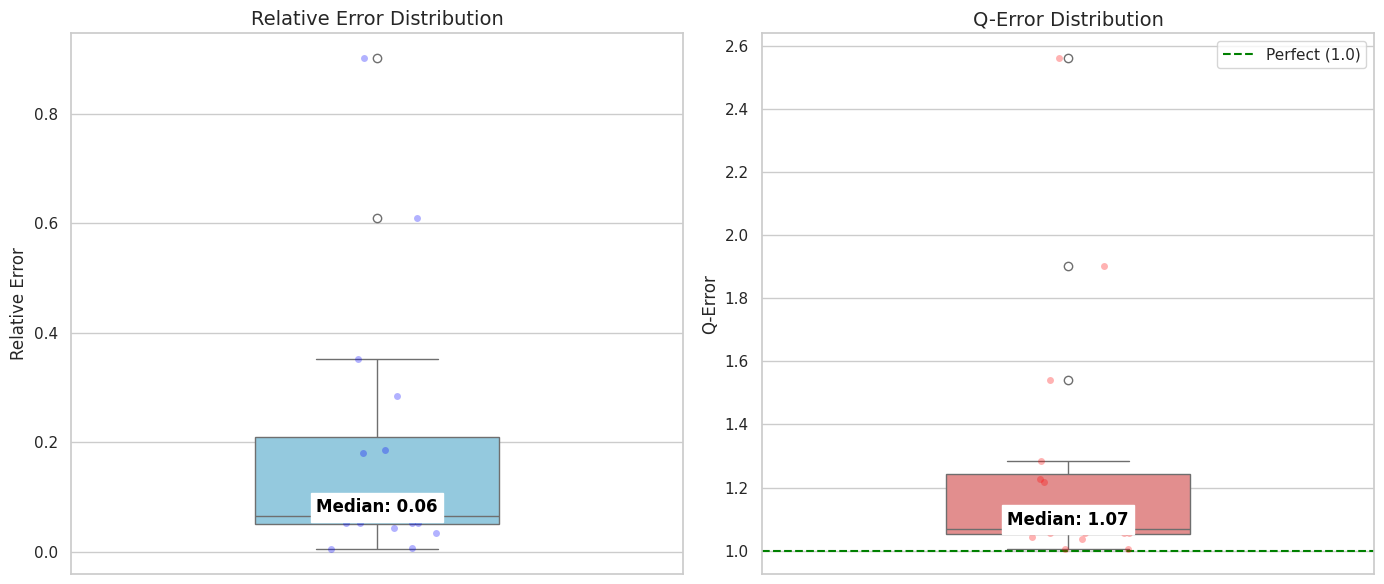

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# ==========================================
# 配置你的文件路径
# ==========================================
TRUTH_FILE_PATH = '/home/wangshuo/resource/datasets/parler_data/dataset_three/ground_truth/parler_ans.txt'        # 真实值文件路径
ESTIMATE_FILE_PATH = '/home/wangshuo/projects/alley-main/results/parler_alley_query.txt'  # 估计值文件路径

# ==========================================
# 1. 数据解析函数
# ==========================================

def get_base_name(filename):
    """移除扩展名和路径，只保留核心文件名"""
    # 移除路径
    basename = os.path.basename(filename)
    # 移除 .graph 或 .txt 后缀
    return basename.replace('.graph', '').replace('.txt', '')

def load_truth_data(filepath):
    """读取真实基数文件"""
    truth_map = {}
    try:
        with open(filepath, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) < 3: 
                    continue
                # 格式: filename duration cardinality
                name = get_base_name(parts[0])
                card = float(parts[2])
                truth_map[name] = card
        print(f"成功加载真实值文件，共 {len(truth_map)} 条记录。")
    except FileNotFoundError:
        print(f"[Error] 找不到文件: {filepath}")
    return truth_map

def load_estimate_data(filepath):
    """读取估计结果文件"""
    est_list = []
    try:
        with open(filepath, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if not parts: continue
                
                # 过滤掉以数字开头的行（这是内部log行，如 '2 2059...'）
                if parts[0][0].isdigit():
                    continue
                
                # 格式: path/to/file estimated_cardinality ...
                name = get_base_name(parts[0])
                est = float(parts[1])
                est_list.append((name, est))
        print(f"成功加载估计值文件，共 {len(est_list)} 条记录。")
    except FileNotFoundError:
        print(f"[Error] 找不到文件: {filepath}")
    return est_list

# ==========================================
# 2. 误差计算与分析
# ==========================================

def process_and_visualize(truth_file, est_file):
    # 1. 加载数据
    truth_dict = load_truth_data(truth_file)
    estimates = load_estimate_data(est_file)
    
    if not truth_dict or not estimates:
        print("数据加载失败，无法进行计算。")
        return

    results = []
    
    print("\n" + "="*85)
    print(f"{'Query Name':<25} | {'True Card':<12} | {'Est Card':<12} | {'Rel Error':<10} | {'Q-Error':<10}")
    print("="*85)
    
    # 2. 匹配并计算
    for name, est_val in estimates:
        if name not in truth_dict:
            print(f"[Warning] '{name}' 在真实值文件中未找到，跳过。")
            continue
            
        true_val = truth_dict[name]
        
        # --- 计算相对误差 (Relative Error) ---
        # Formula: |Est - True| / True
        if true_val == 0:
            rel_error = 0.0 if est_val == 0 else float('inf')
        else:
            rel_error = abs(est_val - true_val) / true_val
            
        # --- 计算 Q-Error ---
        # Formula: max(Est/True, True/Est)
        # 使用 max(1, x) 防止除以零错误，这是基数估计的标准做法
        t = max(1.0, true_val)
        e = max(1.0, est_val)
        q_error = max(e/t, t/e)
        
        results.append({
            'Query': name,
            'Relative Error': rel_error,
            'Q-Error': q_error
        })
        
        print(f"{name:<25} | {int(true_val):<12} | {int(est_val):<12} | {rel_error:.4f}     | {q_error:.4f}")

    if not results:
        print("没有匹配的查询数据。")
        return

    df = pd.DataFrame(results)
    
    # 3. 打印统计摘要
    print("\n" + "="*30)
    print("       统计摘要       ")
    print("="*30)
    print(df[['Relative Error', 'Q-Error']].describe())

    # 4. 绘图
    plot_results(df)

def plot_results(df):
    sns.set(style="whitegrid")
    
    # 创建画布
    plt.figure(figsize=(14, 6))

    # --- 左图：相对误差 ---
    plt.subplot(1, 2, 1)
    sns.boxplot(y=df['Relative Error'], color='skyblue', width=0.4)
    sns.stripplot(y=df['Relative Error'], color='blue', alpha=0.3, jitter=True) # 添加散点看分布
    plt.title('Relative Error Distribution', fontsize=14)
    plt.ylabel('Relative Error', fontsize=12)
    
    # 标出中位数
    median_re = df['Relative Error'].median()
    plt.text(0, median_re, f'Median: {median_re:.2f}', 
             ha='center', va='bottom', color='black', fontweight='bold', backgroundcolor='white')

    # --- 右图：Q-Error ---
    plt.subplot(1, 2, 2)
    sns.boxplot(y=df['Q-Error'], color='lightcoral', width=0.4)
    sns.stripplot(y=df['Q-Error'], color='red', alpha=0.3, jitter=True)
    plt.title('Q-Error Distribution', fontsize=14)
    plt.ylabel('Q-Error', fontsize=12)
    # 画一条基准线 y=1 (完美估计)
    plt.axhline(y=1, color='green', linestyle='--', label='Perfect (1.0)')
    plt.legend()
    
    # 标出中位数
    median_qe = df['Q-Error'].median()
    plt.text(0, median_qe, f'Median: {median_qe:.2f}', 
             ha='center', va='bottom', color='black', fontweight='bold', backgroundcolor='white')

    plt.tight_layout()
    plt.show()

# ==========================================
# 程序入口
# ==========================================
if __name__ == "__main__":
    # 检查文件是否存在
    if os.path.exists(TRUTH_FILE_PATH) and os.path.exists(ESTIMATE_FILE_PATH):
        process_and_visualize(TRUTH_FILE_PATH, ESTIMATE_FILE_PATH)
    else:
        print("错误：请确保当前目录下存在 'parler_ans.txt' 和 'parler_alley_query.txt' 文件。")

#### 1.3.2 相对误差和相对Q_error
计算不带ML谓词的ALLey 估计和 GT的误差箱型图

成功加载真实值，共 246 条。
成功加载估计值，共 246 条。

Query Name                | True       | Est        | Signed RelErr | Signed Q-Err
query_cycle_6_156         | 37688243   | 40160894   | +0.0656        | +1.0656
query_path_6_66           | 24026718   | 10529700   | -0.5618        | -2.2818
query_cycle_6_167         | 1632383    | 1606647    | -0.0158        | -1.0160
query_cycle_6_182         | 67481245   | 36301719   | -0.4620        | -1.8589
query_path_6_116          | 9746244    | 5938717    | -0.3907        | -1.6411
query_path_6_123          | 43450497   | 18106277   | -0.5833        | -2.3997
query_cycle_6_62          | 3957294    | 3237726    | -0.1818        | -1.2222
query_path_6_76           | 12558906   | 7465695    | -0.4055        | -1.6822
query_path_6_55           | 17184947   | 8191042    | -0.5234        | -2.0980
query_cycle_8_254         | 4206621    | 3231418    | -0.2318        | -1.3018
query_path_6_62           | 43450497   | 18541971   | -0.5733        | -2.3434
query_path_6_

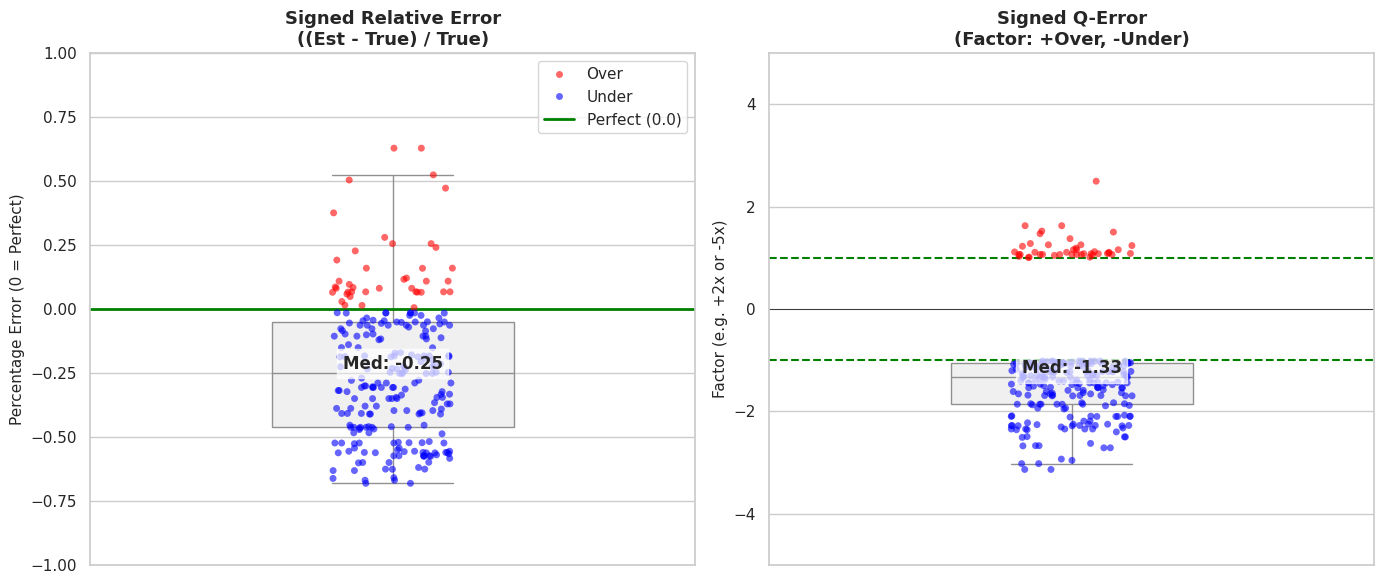

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import numpy as np

# ==========================================
# 配置你的文件路径
# ==========================================
dataset = 'dataset_three'
TRUTH_FILE_PATH = f'/home/wangshuo/resource/datasets/parler_data/{dataset}/ground_truth/parler_ans.txt'        # 真实值文件路径
ESTIMATE_FILE_PATH = f'/home/wangshuo/projects/alley-main/results/parler_alley_query.txt'  # 估计值文件路径


# ==========================================
# 1. 数据解析函数 (保持不变)
# ==========================================

def get_base_name(filename):
    basename = os.path.basename(filename)
    return basename.replace('.graph', '').replace('.txt', '')

def load_truth_data(filepath):
    truth_map = {}
    try:
        with open(filepath, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) < 3: continue
                name = get_base_name(parts[0])
                card = float(parts[2])
                truth_map[name] = card
        print(f"成功加载真实值，共 {len(truth_map)} 条。")
    except FileNotFoundError:
        print(f"[Error] 找不到文件: {filepath}")
    return truth_map

def load_estimate_data(filepath):
    est_list = []
    try:
        with open(filepath, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if not parts: continue
                if parts[0][0].isdigit(): continue 
                name = get_base_name(parts[0])
                est = float(parts[1])
                est_list.append((name, est))
        print(f"成功加载估计值，共 {len(est_list)} 条。")
    except FileNotFoundError:
        print(f"[Error] 找不到文件: {filepath}")
    return est_list

# ==========================================
# 2. 核心计算逻辑 (修改部分)
# ==========================================

def process_and_visualize(truth_file, est_file):
    truth_dict = load_truth_data(truth_file)
    estimates = load_estimate_data(est_file)
    
    if not truth_dict or not estimates:
        print("数据不足，停止运行。")
        return

    results = []
    
    print("\n" + "="*105)
    print(f"{'Query Name':<25} | {'True':<10} | {'Est':<10} | {'Signed RelErr':<13} | {'Signed Q-Err':<12}")
    print("="*105)
    
    for name, est_val in estimates:
        if name not in truth_dict:
            continue
            
        true_val = truth_dict[name]
        
        # 防止除以0
        t = max(1.0, true_val)
        e = max(1.0, est_val)
        
        # --- 1. 有符号相对误差 (Signed Relative Error) ---
        # 公式: (Est - True) / True
        # > 0 : 高估 (如 0.5 = 高估50%)
        # < 0 : 低估 (如 -0.9 = 少了90%)
        signed_rel_err = (e - t) / t
            
        # --- 2. 带符号 Q-Error (Signed Q-Error) ---
        # 高估 (>1): 正数 (e.g. 5.0 = 5倍)
        # 低估 (<1): 负数 (e.g. -5.0 = 1/5)
        if e >= t:
            signed_q = e / t
        else:
            signed_q = - (t / e)
        
        results.append({
            'Query': name,
            'Signed Rel Error': signed_rel_err,
            'Signed Q-Error': signed_q,
            'Type': 'Over' if signed_rel_err >= 0 else 'Under' # 用于绘图着色
        })
        
        print(f"{name:<25} | {int(t):<10} | {int(e):<10} | {signed_rel_err:+.4f}        | {signed_q:+.4f}")

    if not results:
        return

    df = pd.DataFrame(results)
    
    print("\n" + "="*30)
    print("       统计摘要       ")
    print("="*30)
    print(df[['Signed Rel Error', 'Signed Q-Error']].describe())

    plot_results(df)

# ==========================================
# 3. 绘图 (修改部分：双向坐标轴)
# ==========================================

# def plot_results(df):
#     sns.set(style="whitegrid")
#     plt.figure(figsize=(14, 6))

#     # 定义颜色字典
#     palette = {'Over': 'red', 'Under': 'blue'}

#     # --- 左图：有符号相对误差 ---
#     plt.subplot(1, 2, 1)
    
#     # 画箱型图 (灰色背景)
#     sns.boxplot(y=df['Signed Rel Error'], color='#f0f0f0', width=0.4, showfliers=False)
#     # 画散点图 (按高估/低估着色)
#     sns.stripplot(y=df['Signed Rel Error'], hue=df['Type'], palette=palette, alpha=0.6, jitter=True)
    
#     plt.title('Signed Relative Error\n((Est - True) / True)', fontsize=13, fontweight='bold')
#     plt.ylabel('Percentage Error (0 = Perfect)', fontsize=11)
    
#     # 完美线 (0)
#     plt.axhline(y=0, color='green', linestyle='-', linewidth=2, label='Perfect (0.0)')
    
#     # 标出中位数
#     med_rel = df['Signed Rel Error'].median()
#     plt.text(0, med_rel, f'Med: {med_rel:+.2f}', ha='center', va='bottom', 
#              fontweight='bold', bbox=dict(facecolor='white', alpha=0.7))
#     plt.legend(loc='upper right')

#     # --- 右图：带符号 Q-Error ---
#     plt.subplot(1, 2, 2)
    
#     sns.boxplot(y=df['Signed Q-Error'], color='#f0f0f0', width=0.4, showfliers=False)
#     sns.stripplot(y=df['Signed Q-Error'], hue=df['Type'], palette=palette, alpha=0.6, jitter=True)

#     plt.title('Signed Q-Error\n(Factor: +Over, -Under)', fontsize=13, fontweight='bold')
#     plt.ylabel('Factor (e.g. +2x or -5x)', fontsize=11)
    
#     # 参考线
#     plt.axhline(y=1, color='green', linestyle='--', linewidth=1.5, label='Perfect (+1.0)')
#     plt.axhline(y=-1, color='green', linestyle='--', linewidth=1.5) 
#     plt.axhline(y=0, color='black', linewidth=0.5) 
    
#     # 标出中位数
#     med_q = df['Signed Q-Error'].median()
#     plt.text(0, med_q, f'Med: {med_q:+.2f}', ha='center', va='bottom', 
#              fontweight='bold', bbox=dict(facecolor='white', alpha=0.7))
    
#     plt.legend().remove() # 移除右图重复的图例

#     plt.tight_layout()
#     plt.show()

def plot_results(df, rel_ylim=(-1.0, 1.0), q_ylim=(-5.0, 5.0), whis=1.5):
    sns.set(style="whitegrid")
    plt.figure(figsize=(14, 6))

    palette = {'Over': 'red', 'Under': 'blue'}

    # --- 左图：有符号相对误差 ---
    ax1 = plt.subplot(1, 2, 1)
    sns.boxplot(y=df['Signed Rel Error'], color='#f0f0f0', width=0.4, showfliers=False, whis=whis, ax=ax1)

    # 只绘制在 rel_ylim 范围内的散点
    low, high = rel_ylim
    df_rel_in = df[(df['Signed Rel Error'] >= low) & (df['Signed Rel Error'] <= high)]
    omitted_rel = len(df) - len(df_rel_in)
    sns.stripplot(y=df_rel_in['Signed Rel Error'], hue=df_rel_in['Type'], palette=palette,
                  alpha=0.6, jitter=True, ax=ax1)

    ax1.set_title('Signed Relative Error\n((Est - True) / True)', fontsize=13, fontweight='bold')
    ax1.set_ylabel('Percentage Error (0 = Perfect)', fontsize=11)
    ax1.axhline(y=0, color='green', linestyle='-', linewidth=2, label='Perfect (0.0)')
    med_rel = df['Signed Rel Error'].median()
    ax1.text(0, med_rel, f'Med: {med_rel:+.2f}', ha='center', va='bottom',
             fontweight='bold', bbox=dict(facecolor='white', alpha=0.7))
    ax1.legend(loc='upper right')
    ax1.set_ylim(low, high)

    # --- 右图：带符号 Q-Error ---
    ax2 = plt.subplot(1, 2, 2)
    sns.boxplot(y=df['Signed Q-Error'], color='#f0f0f0', width=0.4, showfliers=False, whis=whis, ax=ax2)

    qlow, qhigh = q_ylim
    df_q_in = df[(df['Signed Q-Error'] >= qlow) & (df['Signed Q-Error'] <= qhigh)]
    omitted_q = len(df) - len(df_q_in)
    sns.stripplot(y=df_q_in['Signed Q-Error'], hue=df_q_in['Type'], palette=palette,
                  alpha=0.6, jitter=True, ax=ax2)

    ax2.set_title('Signed Q-Error\n(Factor: +Over, -Under)', fontsize=13, fontweight='bold')
    ax2.set_ylabel('Factor (e.g. +2x or -5x)', fontsize=11)
    ax2.axhline(y=1, color='green', linestyle='--', linewidth=1.5, label='Perfect (+1.0)')
    ax2.axhline(y=-1, color='green', linestyle='--', linewidth=1.5)
    ax2.axhline(y=0, color='black', linewidth=0.5)

    med_q = df['Signed Q-Error'].median()
    ax2.text(0, med_q, f'Med: {med_q:+.2f}', ha='center', va='bottom',
             fontweight='bold', bbox=dict(facecolor='white', alpha=0.7))
    # 移除重复图例
    ax2.legend_.remove() if ax2.legend_ else None
    ax2.set_ylim(qlow, qhigh)

    plt.tight_layout()
    # 打印被省略的点数（可选）
    print(f"[INFO] 左图省略点数: {omitted_rel}, 右图省略点数: {omitted_q}")
    plt.show()
if __name__ == "__main__":
    if os.path.exists(TRUTH_FILE_PATH) and os.path.exists(ESTIMATE_FILE_PATH):
        process_and_visualize(TRUTH_FILE_PATH, ESTIMATE_FILE_PATH)
    else:
        print("错误：请确保文件存在。")

#### 1.3.3 相对误差和相对Q_error
计算带ML谓词的ALLey 估计和 GT的误差箱型图

成功加载真实值 (JSON)，共 246 条。
成功加载估计值，共 246 条。

=== Summary Statistics ===
       Signed Rel Error  Q-Error (ratio)  Signed Log2 Q-Error
count        246.000000       246.000000           246.000000
mean           0.030887         1.357466            -0.058744
std            0.446419         0.408904             0.523572
min           -0.663494         1.001929            -1.571298
25%           -0.259983         1.094576            -0.434461
50%           -0.061172         1.241731            -0.091074
75%            0.111367         1.462579             0.152335
max            2.540418         3.540418             1.823920

[Visual Info] 左图隐藏了 13 个超出范围点, 右图隐藏了 0 个超出范围点。


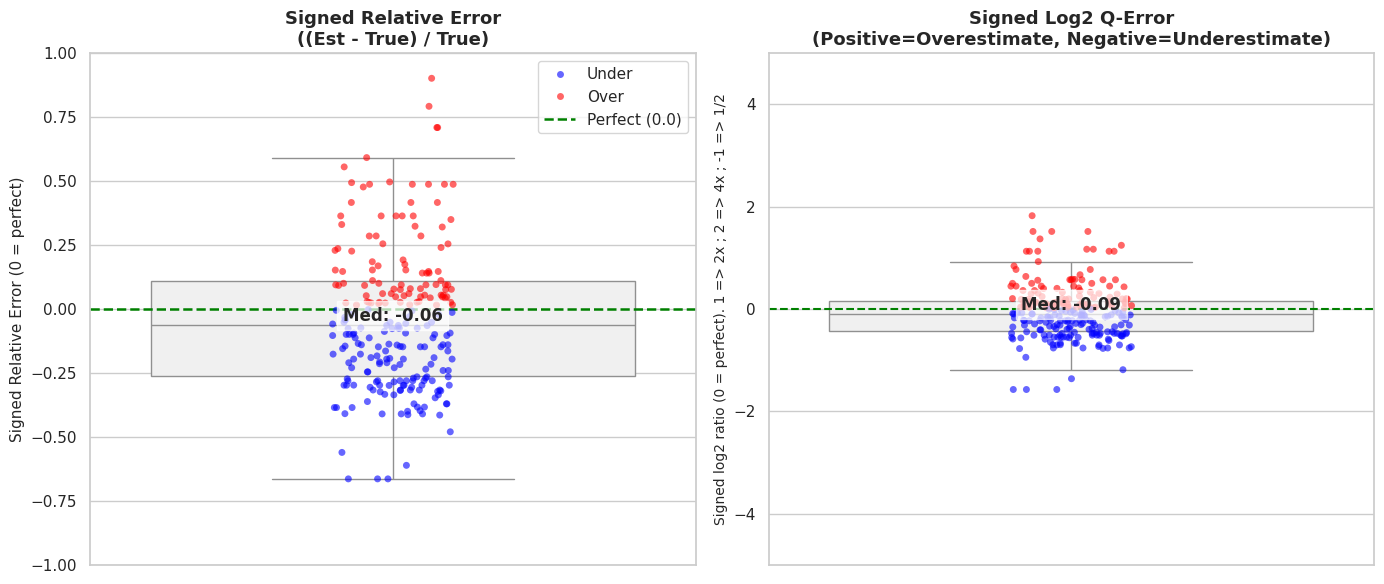

In [1]:
import os
import json
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 配置路径（按需修改）
dataset = 'dataset_three'
TRUTH_FILE_PATH = f'/home/wangshuo/resource/datasets/parler_data/{dataset}/ground_truth/T_true_Dist_Bimodal_left_oracle_prob.txt'
ESTIMATE_FILE_PATH = f'/home/wangshuo/projects/alley-main/results/parler_alley_query.txt'

def get_base_name(filename):
    basename = os.path.basename(filename)
    return basename.replace('.graph', '').replace('.txt', '')

def load_truth_data(filepath):
    """假设 truth 文件是 JSON: { "query_name": value, ... }"""
    truth_map = {}
    try:
        with open(filepath, 'r') as f:
            data = json.load(f)
        for key, val in data.items():
            name = get_base_name(key)
            truth_map[name] = float(val)
        print(f"成功加载真实值 (JSON)，共 {len(truth_map)} 条。")
    except Exception as e:
        print(f"[Error] 读取真实值失败: {e}")
    return truth_map

def load_estimate_data(filepath):
    """解析 Alley 输出估计文件: 每行类似 '.../query.txt 12345 ...'，跳过以数字开头的日志行"""
    est_list = []
    try:
        with open(filepath, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if not parts:
                    continue
                if parts[0][0].isdigit():
                    continue
                name = get_base_name(parts[0])
                try:
                    est = float(parts[1])
                except:
                    # 如果无法转为 float，跳过
                    continue
                est_list.append((name, est))
        print(f"成功加载估计值，共 {len(est_list)} 条。")
    except Exception as e:
        print(f"[Error] 读取估计值失败: {e}")
    return est_list

def compute_signed_log2_q(true_val, est_val):
    """按照论文：使用 max(1,w) 的保护，并返回 signed log2 q-error"""
    t = max(1.0, float(true_val))
    e = max(1.0, float(est_val))
    if e >= t:
        # 高估：正值，log2(e/t)
        return math.log2(e / t)
    else:
        # 低估：负值，-log2(t/e)
        return -math.log2(t / e)

def process_and_visualize(truth_file, est_file, rel_ylim=(-1.0, 1.0), logq_ylim=(-5.0, 5.0)):
    truth = load_truth_data(truth_file)
    estimates = load_estimate_data(est_file)
    if not truth or not estimates:
        print("数据不足，停止。")
        return

    records = []
    for name, est_val in estimates:
        if name not in truth:
            # 可选打印提示
            # print(f"[Warn] {name} 在 truth 中未找到，跳过。")
            continue
        true_val = truth[name]
        # 相对误差（signed relative error）使用保护后的值以与论文绘图一致：
        t = max(1.0, float(true_val))
        e = max(1.0, float(est_val))
        signed_rel = (e - t) / t  # >0 高估, <0 低估

        # 无符号 ratio Q-error（常见指标）
        ratio_q = max(e / t, t / e)

        # 按论文：signed 对数 Q-error，底为 2（log2）
        signed_log2_q = compute_signed_log2_q(true_val, est_val)

        records.append({
            'Query': name,
            'True': t,
            'Est': e,
            'Signed Rel Error': signed_rel,
            'Q-Error (ratio)': ratio_q,
            'Signed Log2 Q-Error': signed_log2_q,
            'Type': 'Over' if signed_rel >= 0 else 'Under'
        })

    if not records:
        print("[Error] 没有匹配数据。")
        return

    df = pd.DataFrame(records)
    # 打印摘要统计
    print("\n=== Summary Statistics ===")
    print(df[['Signed Rel Error', 'Q-Error (ratio)', 'Signed Log2 Q-Error']].describe())

    # 绘图：左图为 Signed Relative Error（以 0 为中心），右图为 Signed Log2 Q-Error（以 0 为中心）
    plot_signed_rel_and_logq(df, rel_ylim=rel_ylim, logq_ylim=logq_ylim)

def plot_signed_rel_and_logq(df, rel_ylim=(-1.0, 1.0), logq_ylim=(-5.0, 5.0), whis=1.5):
    sns.set(style="whitegrid")
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    palette = {'Over': 'red', 'Under': 'blue'}

    # 左：Signed Relative Error
    ax1 = axes[0]
    sns.boxplot(y=df['Signed Rel Error'], color='#f0f0f0', showfliers=False, whis=whis, ax=ax1)
    low, high = rel_ylim
    df_rel_in = df[(df['Signed Rel Error'] >= low) & (df['Signed Rel Error'] <= high)]
    omitted_rel = len(df) - len(df_rel_in)
    sns.stripplot(y=df_rel_in['Signed Rel Error'], hue=df_rel_in['Type'], palette=palette, alpha=0.6, jitter=True, ax=ax1)
    ax1.set_title('Signed Relative Error\n((Est - True) / True)', fontsize=13, fontweight='bold')
    ax1.set_ylabel('Signed Relative Error (0 = perfect)', fontsize=11)
    ax1.axhline(0, color='green', linewidth=1.8, linestyle='--', label='Perfect (0.0)')
    med_rel = df['Signed Rel Error'].median()
    ax1.text(0, med_rel, f'Med: {med_rel:+.2f}', ha='center', va='bottom', fontweight='bold', bbox=dict(facecolor='white', alpha=0.7))
    ax1.legend(loc='upper right')
    ax1.set_ylim(low, high)

    # 右：Signed Log2 Q-Error (论文中用 log10，这里改为 log2)
    ax2 = axes[1]
    sns.boxplot(y=df['Signed Log2 Q-Error'], color='#f0f0f0', showfliers=False, whis=whis, ax=ax2)
    qlow, qhigh = logq_ylim
    df_q_in = df[(df['Signed Log2 Q-Error'] >= qlow) & (df['Signed Log2 Q-Error'] <= qhigh)]
    omitted_q = len(df) - len(df_q_in)
    sns.stripplot(y=df_q_in['Signed Log2 Q-Error'], hue=df_q_in['Type'], palette=palette, alpha=0.6, jitter=True, ax=ax2)
    ax2.set_title('Signed Log2 Q-Error\n(Positive=Overestimate, Negative=Underestimate)', fontsize=13, fontweight='bold')
    ax2.set_ylabel('Signed log2 ratio (0 = perfect). 1 => 2x ; 2 => 4x ; -1 => 1/2', fontsize=10)
    ax2.axhline(0, color='green', linestyle='--', linewidth=1.5, label='Perfect (0)')
    med_logq = df['Signed Log2 Q-Error'].median()
    ax2.text(0, med_logq, f'Med: {med_logq:+.2f}', ha='center', va='bottom', fontweight='bold', bbox=dict(facecolor='white', alpha=0.7))
    # 移除重复图例
    if ax2.legend_:
        ax2.legend_.remove()
    ax2.set_ylim(qlow, qhigh)

    plt.tight_layout()
    print(f"\n[Visual Info] 左图隐藏了 {omitted_rel} 个超出范围点, 右图隐藏了 {omitted_q} 个超出范围点。")
    plt.show()

if __name__ == "__main__":
    if os.path.exists(TRUTH_FILE_PATH) and os.path.exists(ESTIMATE_FILE_PATH):
        process_and_visualize(TRUTH_FILE_PATH, ESTIMATE_FILE_PATH)
    else:
        print(f"错误：文件不存在。\n检查路径:\n1. {TRUTH_FILE_PATH}\n2. {ESTIMATE_FILE_PATH}")